In [13]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Konfiguration


In [14]:
BASE_DIR = Path(".")

# Define input file paths.
BUTTER_FILE = BASE_DIR / "eurostat_butter_cpi.json"
PPI_FILE = BASE_DIR / "eurostat_ppi_dairy.json"

# Define the temporary VAT reduction period in Germany.
VAT_START = pd.Timestamp("2020-07-01")
VAT_END = pd.Timestamp("2020-12-31")

# Define the comparison period for the inflation surge in 2021.
INFLATION_2021_START = pd.Timestamp("2021-01-01")
INFLATION_2021_END = pd.Timestamp("2021-12-31")

# Define the overall analysis window.
ANALYSIS_START = pd.Timestamp("2019-01-01")
ANALYSIS_END = pd.Timestamp("2021-12-31")

## 2. Function: Convert Eurostat-JSON into a DataFrame 


In [15]:
def eurostat_json_to_df(file_path: Path, value_name: str) -> pd.DataFrame:
    """
    Convert a Eurostat-style JSON file into a tidy monthly pandas DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to the input JSON file.
    value_name : str
        Name of the output value column.

    Returns
    -------
    pd.DataFrame
        DataFrame with monthly dates and one numeric value column.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]

    time_index_df = (
        pd.Series(time_index, name="position")
        .rename_axis("label_key")
        .reset_index()
    )

    time_labels_df = (
        pd.Series(time_labels, name="date_raw")
        .rename_axis("label_key")
        .reset_index()
    )

    values_df = (
        pd.Series(values, name=value_name)
        .rename_axis("position_str")
        .reset_index()
    )

    values_df["position"] = pd.to_numeric(
        values_df["position_str"],
        errors="coerce",
    )

    df = (
        time_index_df
        .merge(time_labels_df, on="label_key", how="left")
        .merge(values_df[[ "position", value_name]], on="position", how="left")
    )

    df["date"] = pd.to_datetime(
        df["date_raw"].str.replace("M", "-", regex=False),
        format="%Y-%m",
        errors="coerce",
    )

    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    df = df.drop(columns=["label_key", "position", "date_raw"])

    return df

## 3. Function: clean_time_series()




In [16]:
def clean_time_series(df: pd.DataFrame, value_column: str) -> pd.DataFrame:
    """
    Clean and prepare a time series DataFrame for analysis.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a date column and a value column.
    value_column : str
        Name of the column containing the time series values.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame sorted by date and filtered to the analysis window
    """
    # Keep only rows inside the defined analysis period
    df = df[(df["date"] >= ANALYSIS_START) & (df["date"] <= ANALYSIS_END)]

    # Remove rows where the value is missing
    df = df.dropna(subset=[value_column])

    # Sort the time series chronologically
    df = df.sort_values("date")

    # Reset index after filtering and sorting
    df = df.reset_index(drop=True)

    return df

## 4. Function: merge_series()


In [17]:
def merge_series(butter_df: pd.DataFrame, ppi_df: pd.DataFrame) -> pd.DataFrame:
    """
    Parameters
    ----------
    butter_df : pd.DataFrame
        DataFrame containing butter CPI values.
    ppi_df : pd.DataFrame
        DataFrame containing dairy PPI values.

    Returns
    -------
    pd.DataFrame
        Merged DataFrame containing both indices and derived metrics.
    """

    # Merge both datasets using the common monthly date column
    merged_df = pd.merge(butter_df, ppi_df, on="date", how="inner")
    
    # Sort observations chronologically and reset the index
    merged_df = merged_df.sort_values("date").reset_index(drop=True)

    # Calculates month-over-month percentage changes
    # This shows short-term price movements
    merged_df["butter_mom_pct"] = merged_df["butter_cpi"].pct_change() * 100
    merged_df["dairy_ppi_mom_pct"] = merged_df["dairy_ppi"].pct_change() * 100
    
    # Calculates year-over-year percentage changes
    # This captures longer inflation trends
    merged_df["butter_yoy_pct"] = merged_df["butter_cpi"].pct_change(12) * 100
    merged_df["dairy_ppi_yoy_pct"] = merged_df["dairy_ppi"].pct_change(12) * 100

    # Compute the gap between consumer and producer price indices
    # This can indicate differences between retail prices and production costs
    merged_df["index_gap"] = merged_df["butter_cpi"] - merged_df["dairy_ppi"]

    return merged_df

def add_policy_and_period_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add policy-related and time-based features to the dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a monthly date column.

    Returns
    -------
    pd.DataFrame
        DataFrame enriched with VAT dummy, year, month, and period labels.
    """
    enriched_df = df.copy()

    enriched_df["vat_dummy"] = (
        (enriched_df["date"] >= VAT_START) &
        (enriched_df["date"] <= VAT_END)
    ).astype(int)

    enriched_df["year"] = enriched_df["date"].dt.year
    enriched_df["month"] = enriched_df["date"].dt.month

    enriched_df["period"] = np.select(
        [
            (enriched_df["date"] >= pd.Timestamp("2019-01-01")) &
            (enriched_df["date"] <= pd.Timestamp("2020-06-30")),

            (enriched_df["date"] >= VAT_START) &
            (enriched_df["date"] <= VAT_END),

            (enriched_df["date"] >= INFLATION_2021_START) &
            (enriched_df["date"] <= INFLATION_2021_END),
        ],
        [
            "before_vat",
            "during_vat",
            "inflation_2021",
        ],
        default="other",
    )

    return enriched_df
    
def print_data_quality_report(df: pd.DataFrame) -> None:
    """
    Print a compact data quality report for the given DataFrame.

    The report includes:
    - number of rows
    - date range
    - missing values per column
    - number of duplicate dates
    """

    print("=" * 70)
    print("DATA QUALITY REPORT")
    print("=" * 70)

    # Number of observations in the dataset
    print(f"Number of rows: {len(df)}")

    # Display the time span of the dataset
    print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

    # Show missing values per column
    print("\nMissing values per column:")
    print(df.isna().sum())

    # Check for duplicated dates
    duplicate_dates = df["date"].duplicated().sum()
    print(f"\nDuplicate dates: {duplicate_dates}")

    print("=" * 70)

## 5. Functions: Key figures and interpretaion 


In [18]:
def get_single_value(df: pd.DataFrame, date_string: str, column_name: str) -> float:
    """
    Return the value of a selected column for one specific month.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing a monthly date column.
    date_string : str
        Target date in YYYY-MM-DD format.
    column_name : str
        Name of the column from which the value should be retrieved.

    Returns
    -------
    float
        Numeric value for the selected month and column.
    """
    target_date = pd.Timestamp(date_string)
    subset = df.loc[df["date"] == target_date, column_name]
    #wenn der Monat fehlt, wird sauber ein ValueError geworfen, statt stillschweigend falsche werte zurückgegeben werden!!!
    if subset.empty:
        raise ValueError(
            f"Missing required observation for {date_string} in column {column_name}."
        )

    return float(subset.iloc[0])


def calculate_phase_effects(df: pd.DataFrame) -> dict:
    """
    Calculate the butter CPI change, dairy PPI change, and CPI-PPI gap change
    during the VAT phase and during the inflation period in 2021.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing butter CPI, dairy PPI, and gap time series.

    Returns
    -------
    dict
        Dictionary with phase-specific start values, end values,
        percentage changes, gap changes, and the inflation offset ratio.
    """

    # VAT phase values
    vat_butter_start = get_single_value(df, "2020-07-01", "butter_cpi")
    vat_butter_end = get_single_value(df, "2020-12-01", "butter_cpi")

    vat_dairy_start = get_single_value(df, "2020-07-01", "dairy_ppi")
    vat_dairy_end = get_single_value(df, "2020-12-01", "dairy_ppi")

    vat_gap_start = get_single_value(df, "2020-07-01", "index_gap")
    vat_gap_end = get_single_value(df, "2020-12-01", "index_gap")

    # Inflation period in 2021 values
    infl_butter_start = get_single_value(df, "2021-01-01", "butter_cpi")
    infl_butter_end = get_single_value(df, "2021-12-01", "butter_cpi")

    infl_dairy_start = get_single_value(df, "2021-01-01", "dairy_ppi")
    infl_dairy_end = get_single_value(df, "2021-12-01", "dairy_ppi")

    infl_gap_start = get_single_value(df, "2021-01-01", "index_gap")
    infl_gap_end = get_single_value(df, "2021-12-01", "index_gap")

    # Percentage changes
    vat_effect_pct = ((vat_butter_end - vat_butter_start) / vat_butter_start) * 100
    inflation_2021_pct = ((infl_butter_end - infl_butter_start) / infl_butter_start) * 100

    vat_dairy_pct = ((vat_dairy_end - vat_dairy_start) / vat_dairy_start) * 100
    inflation_2021_dairy_pct = ((infl_dairy_end - infl_dairy_start) / infl_dairy_start) * 100

    # Gap changes
    vat_gap_change = vat_gap_end - vat_gap_start
    inflation_2021_gap_change = infl_gap_end - infl_gap_start

    # Offset ratio
    offset_ratio = np.where(
        vat_effect_pct != 0,
        inflation_2021_pct / abs(vat_effect_pct),
        np.nan,
    ).item()

    return {
        "vat_butter_start": vat_butter_start,
        "vat_butter_end": vat_butter_end,
        "vat_effect_pct": vat_effect_pct,
        "vat_dairy_start": vat_dairy_start,
        "vat_dairy_end": vat_dairy_end,
        "vat_dairy_pct": vat_dairy_pct,
        "vat_gap_start": vat_gap_start,
        "vat_gap_end": vat_gap_end,
        "vat_gap_change": vat_gap_change,
        "infl_butter_start": infl_butter_start,
        "infl_butter_end": infl_butter_end,
        "inflation_2021_pct": inflation_2021_pct,
        "infl_dairy_start": infl_dairy_start,
        "infl_dairy_end": infl_dairy_end,
        "inflation_2021_dairy_pct": inflation_2021_dairy_pct,
        "infl_gap_start": infl_gap_start,
        "infl_gap_end": infl_gap_end,
        "inflation_2021_gap_change": inflation_2021_gap_change,
        "offset_ratio": offset_ratio,
    }


def print_interpretation(results: dict) -> None:
    """
    Print a compact interpretation of the VAT-phase effect
    and the inflation offset in 2021.

    Parameters
    ----------
    results : dict
        Dictionary containing the calculated phase effects.
    """
    vat_effect_pct = results["vat_effect_pct"]
    inflation_2021_pct = results["inflation_2021_pct"]
    offset_ratio = results["offset_ratio"]
    vat_gap_change = results["vat_gap_change"]
    inflation_gap_change = results["inflation_2021_gap_change"]

    vat_message = np.select(
        [
            vat_effect_pct < 0,
            vat_effect_pct > 0,
        ],
        [
            (
                "Interpretation: Retail prices fell during the VAT reduction phase, "
                "which suggests at least partial pass-through to consumers."
            ),
            (
                "Interpretation: Retail prices still increased during the VAT phase, "
                "which suggests weak or no visible consumer pass-through."
            ),
        ],
        default="Interpretation: Retail prices were flat during the VAT phase.",
    ).item()

    offset_message = np.select(
        [
            np.isnan(offset_ratio),
            offset_ratio > 1,
        ],
        [
            "Offset ratio cannot be calculated because the VAT effect was zero.",
            "The 2021 inflation surge more than offset the earlier VAT-phase effect.",
        ],
        default="The 2021 inflation surge offset only part of the earlier VAT-phase effect.",
    ).item()

    print("\n" + "=" * 70)
    print("QUESTION 4 – INTERPRETATION")
    print("=" * 70)
    print(f"Butter CPI during VAT phase (Jul–Dec 2020): {vat_effect_pct:.2f}%")
    print(f"Butter CPI during inflation year 2021:     {inflation_2021_pct:.2f}%")
    print(vat_message)
    print(offset_message)
    print(f"CPI-PPI gap change during VAT phase: {vat_gap_change:.2f}")
    print(f"CPI-PPI gap change during inflation 2021: {inflation_gap_change:.2f}")
    print("=" * 70)

## 6. Function: Key figures and interpretation 

In [19]:
def get_plot_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return the subset used for Question 4 visualizations.
    """
    return df.loc[
        df["period"].isin(["before_vat", "during_vat", "inflation_2021"])
    ].copy()

## 7. Reading & Cleaning the Data


In [20]:
# Load the raw Eurostat datasets
butter_raw_df = eurostat_json_to_df(BUTTER_FILE, "butter_cpi")
ppi_raw_df = eurostat_json_to_df(PPI_FILE, "dairy_ppi")

# Clean both time series and restrict them to the analysis period
butter_clean_df = clean_time_series(
    butter_raw_df,
    value_column="butter_cpi"
)

ppi_clean_df = clean_time_series(
    ppi_raw_df,
    value_column="dairy_ppi"
)
# Print the resulting dataset shdapes after cleaning
print("Butter cleaned shape:", butter_clean_df.shape)
print("PPI cleaned shape:", ppi_clean_df.shape)

# Preview the cleaned butter CPI dataset
butter_clean_df.head()

Butter cleaned shape: (36, 2)
PPI cleaned shape: (36, 2)


,butter_cpi,date
0,167.2,2019-01-01
1,162.6,2019-02-01
2,157.6,2019-03-01
3,154.5,2019-04-01
4,153.8,2019-05-01


## 8. Merge time series and create features


In [21]:
# Merge the cleaned butter CPI and dairy PPI time series
analysis_df = merge_series(butter_clean_df, ppi_clean_df)

# Add policy-related features (VAT dummy, year, month, and period labels)
analysis_df = add_policy_and_period_features(analysis_df)

# Run a quick data quality check on the merged dataset
print_data_quality_report(analysis_df)

# Preview the resulting analysis dataset
analysis_df.head()

DATA QUALITY REPORT
Number of rows: 36
Date range: 2019-01-01 to 2021-12-01

Missing values per column:
butter_cpi            0
date                  0
dairy_ppi             0
butter_mom_pct        1
dairy_ppi_mom_pct     1
butter_yoy_pct       12
dairy_ppi_yoy_pct    12
index_gap             0
vat_dummy             0
year                  0
month                 0
period                0
dtype: int64

Duplicate dates: 0


,butter_cpi,date,dairy_ppi,butter_mom_pct,dairy_ppi_mom_pct,butter_yoy_pct,dairy_ppi_yoy_pct,index_gap,vat_dummy,year,month,period
0,167.2,2019-01-01,111.9,NaN,NaN,NaN,NaN,55.3,0,2019,1,before_vat
1,162.6,2019-02-01,112.0,-2.751196,0.089366,NaN,NaN,50.6,0,2019,2,before_vat
2,157.6,2019-03-01,111.1,-3.075031,-0.803571,NaN,NaN,46.5,0,2019,3,before_vat
3,154.5,2019-04-01,110.7,-1.967005,-0.360036,NaN,NaN,43.8,0,2019,4,before_vat
4,153.8,2019-05-01,110.8,-0.453074,0.090334,NaN,NaN,43.0,0,2019,5,before_vat


## 9. Calculation of key figures 


In [22]:
# Calculate the main policy and inflation effects
results = calculate_phase_effects(analysis_df)

results_df = pd.DataFrame(
    {
        "metric": list(results.keys()),
        "value": list(results.values()),
    }
)

results_df["value"] = results_df["value"].round(2)

print("Main metrics:")
print(results_df.to_string(index=False))

print_interpretation(results)

Main metrics:
                   metric  value
         vat_butter_start 140.50
           vat_butter_end 138.60
           vat_effect_pct  -1.35
          vat_dairy_start 109.50
            vat_dairy_end 110.30
            vat_dairy_pct   0.73
            vat_gap_start  31.00
              vat_gap_end  28.30
           vat_gap_change  -2.70
        infl_butter_start 142.10
          infl_butter_end 162.10
       inflation_2021_pct  14.07
         infl_dairy_start 109.70
           infl_dairy_end 124.90
 inflation_2021_dairy_pct  13.86
           infl_gap_start  32.40
             infl_gap_end  37.20
inflation_2021_gap_change   4.80
             offset_ratio  10.41

QUESTION 4 – INTERPRETATION
Butter CPI during VAT phase (Jul–Dec 2020): -1.35%
Butter CPI during inflation year 2021:     14.07%
Interpretation: Retail prices fell during the VAT reduction phase, which suggests at least partial pass-through to consumers.
The 2021 inflation surge more than offset the earlier VAT-phase effect

## 10. Visualization 1: Heatmap


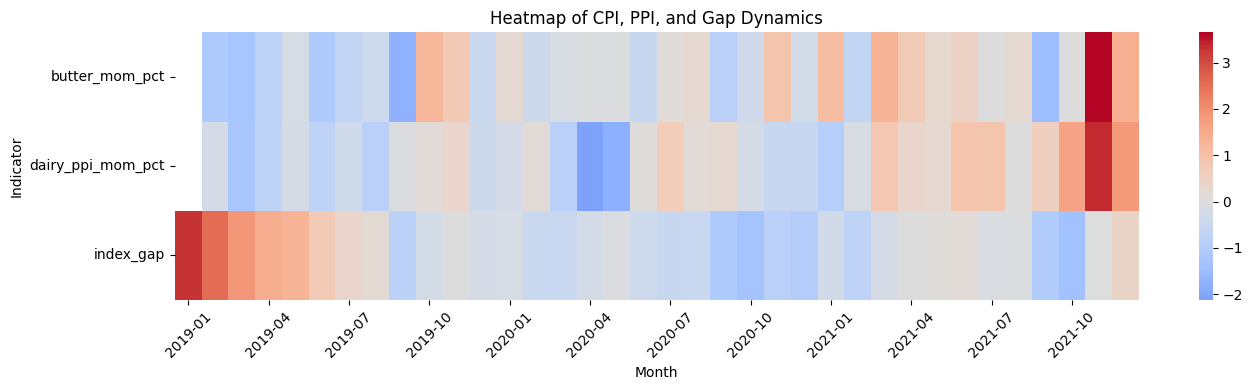

In [23]:
plot_df = get_plot_df(analysis_df)[
    ["date", "butter_mom_pct", "dairy_ppi_mom_pct", "index_gap"]
]

# Format the date column
plot_df["date"] = pd.to_datetime(plot_df["date"]).dt.strftime("%Y-%m")

plot_df = plot_df.set_index("date")

# Standardize values for heatmap comparability
plot_df = ((plot_df - plot_df.mean()) / plot_df.std(ddof=0)).T

plt.figure(figsize=(14,4))
ax = sns.heatmap(plot_df, cmap="coolwarm", center=0)

plt.title("Heatmap of CPI, PPI, and Gap Dynamics")
plt.xlabel("Month")
plt.ylabel("Indicator")

# Show only every 3rd month
ax.set_xticks(ax.get_xticks()[::3])
ax.set_xticklabels(plot_df.columns[::3], rotation=45)

plt.tight_layout()
plt.show()

## 11. Visualization 2: Dumbbell Plot


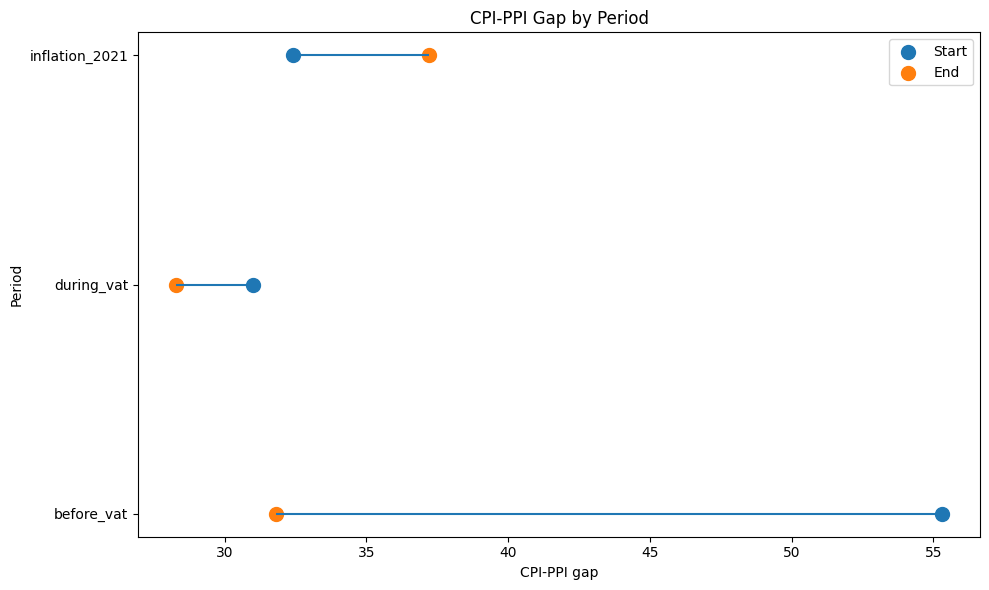

In [24]:
plot_df = (
    get_plot_df(analysis_df)[["date", "period", "index_gap"]]
    .sort_values(["period", "date"])
    .groupby("period", observed=True)
    .agg(gap_start=("index_gap", "first"), gap_end=("index_gap", "last"))
    .reset_index()
)

plot_df["period"] = pd.Categorical(
    plot_df["period"],
    categories=["before_vat", "during_vat", "inflation_2021"],
    ordered=True,
)
plot_df = plot_df.sort_values("period").reset_index(drop=True)
y_pos = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))
plt.hlines(y=y_pos, xmin=plot_df["gap_start"], xmax=plot_df["gap_end"])
plt.scatter(plot_df["gap_start"], y_pos, s=100, label="Start")
plt.scatter(plot_df["gap_end"], y_pos, s=100, label="End")
plt.yticks(y_pos, plot_df["period"])
plt.xlabel("CPI-PPI gap")
plt.ylabel("Period")
plt.title("CPI-PPI Gap by Period")
plt.legend()
plt.tight_layout()
plt.show()